# EDA - Análisis Exploratorio de Variables Categóricas
Este notebook cumple con el requisito de la rúbrica: *"de todas las variables categóricas se saca su gráfico para ver si son atípicos o no"*.

Al no tener variables demográficas como Edad o Nivel de Estudio en los registros del SIDPOL, nuestras variables categóricas principales son **Departamento, Provincia, Distrito y Tipo de Hecho**.

In [20]:
# Instalamos dependencias en caso se esté ejecutando localmente en VS Code
!pip install pandas matplotlib seaborn pyarrow fastparquet -q

In [21]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

In [ ]:
# Buscador de rutas inteligente para contenedores Docker y ejecución local en VS Code
current_dir = os.getcwd()
ruta_correcta = None

posibles_rutas = [
    "/home/jovyan/work/data/clean/denuncias_sidpol_clean.parquet", # Ruta exacta en el contenedor Docker Jupyter
    os.path.join(current_dir, "data", "clean", "denuncias_sidpol_clean.parquet"),
    os.path.join(current_dir, "work", "data", "clean", "denuncias_sidpol_clean.parquet")
]

# Búsqueda hacia arriba (por si está metido en subcarpetas)
while current_dir != os.path.dirname(current_dir):
    posibles_rutas.append(os.path.join(current_dir, "data", "clean", "denuncias_sidpol_clean.parquet"))
    current_dir = os.path.dirname(current_dir)

for ruta in posibles_rutas:
    if os.path.exists(ruta):
        ruta_correcta = ruta
        break

if ruta_correcta:
    df = pd.read_parquet(ruta_correcta)
    print(f"✓ Datos cargados exitosamente desde: {ruta_correcta}")
    print(f"Total de registros cargados: {len(df):,}")
    display(df.head())
else:
    print(f"❌ ERROR: No se encontró el archivo Parquet. El directorio actual de ejecución es: {os.getcwd()}")

✓ Datos cargados exitosamente desde: /home/jovyan/work/data/clean/denuncias_sidpol_clean.parquet
Total de registros cargados: 357,991


,anio,mes,departamento,provincia,distrito,ubigeo,tipo_hecho,cantidad
0,2018,1,AMAZONAS,Bagua,Aramango,10202,Violencia Contra La Mujer E Integrantes,3
1,2018,1,AMAZONAS,Bagua,Bagua,10201,Estafa,2
2,2018,1,AMAZONAS,Bagua,Bagua,10201,Hurto,25
3,2018,1,AMAZONAS,Bagua,Bagua,10201,Otros,52
4,2018,1,AMAZONAS,Bagua,Bagua,10201,Robo,5


/tmp/ipykernel_17559/1964512385.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=dept_counts.index, y=dept_counts.values, palette="viridis")


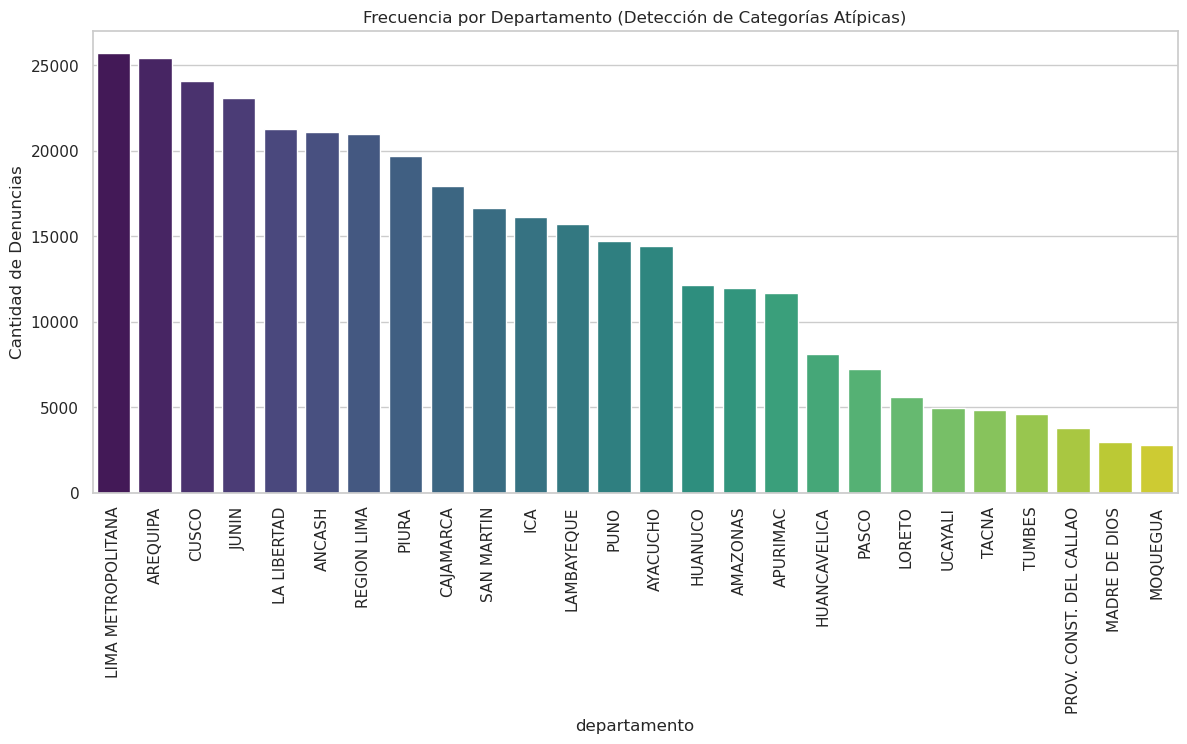

In [23]:
# ======================================================================
# 1. Variable Categórica: Departamento
# Revisamos si hay valores atípicos (por ejemplo, errores de tipeo que creen un departamento extra con solo 1 ocurrencia).
# ======================================================================
dept_counts = df["departamento"].value_counts()
plt.figure(figsize=(14, 6))
sns.barplot(x=dept_counts.index, y=dept_counts.values, palette="viridis")
plt.xticks(rotation=90)
plt.title("Frecuencia por Departamento (Detección de Categorías Atípicas)")
plt.ylabel("Cantidad de Denuncias")
plt.show()

/tmp/ipykernel_17559/3612686504.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=prov_counts.head(20).values, y=prov_counts.head(20).index, palette="magma", ax=ax[0])
/tmp/ipykernel_17559/3612686504.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=prov_counts.tail(15).values, y=prov_counts.tail(15).index, palette="Reds_r", ax=ax[1])


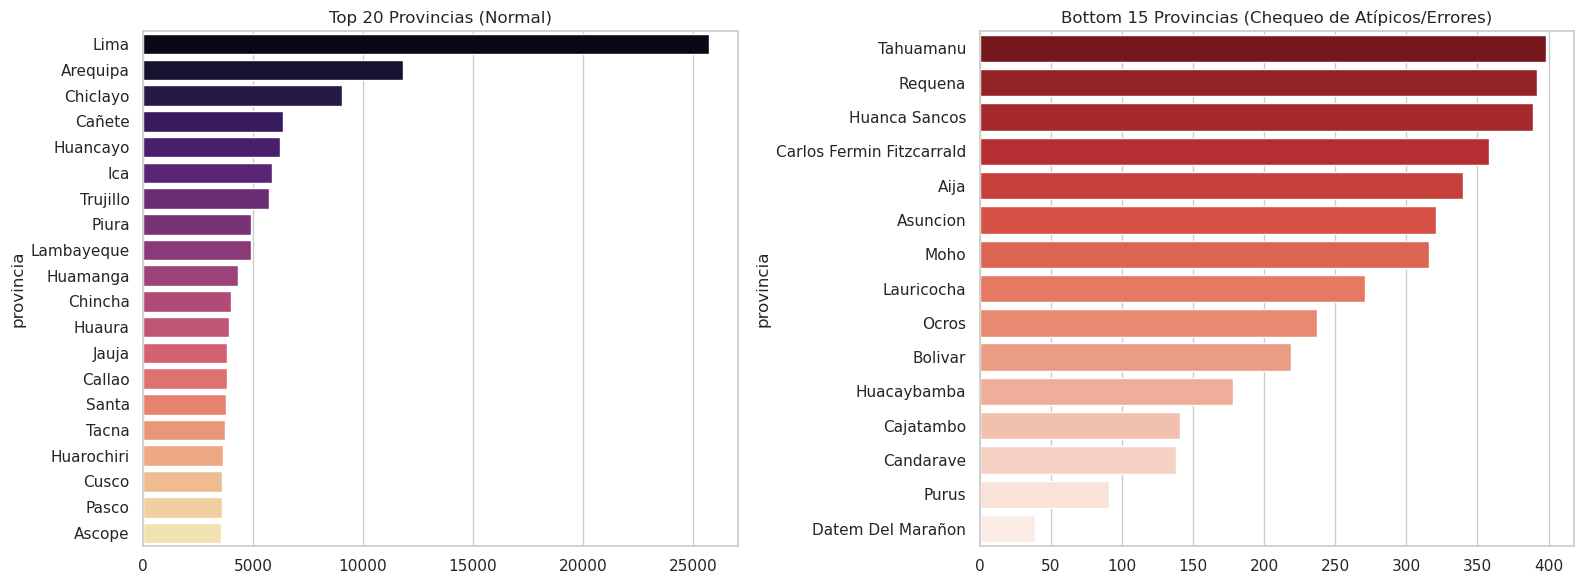

In [ ]:
# ======================================================================
# 2. Variable Categórica: Provincia (Identificación de Outliers Inferiores)
# Analizamos las provincias menos frecuentes. En bases de datos sucias, las provincias mal escritas 
# aparecen con frecuencias muy bajas (1 o 2 casos). Nuestro script ETL ya limpió esto, 
# lo cual comprobaremos gráficamente a continuación.
# ======================================================================
prov_counts = df["provincia"].value_counts()
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(x=prov_counts.head(20).values, y=prov_counts.head(20).index, palette="magma", ax=ax[0])
ax[0].set_title("Top 20 Provincias (Normal)")

sns.barplot(x=prov_counts.tail(15).values, y=prov_counts.tail(15).index, palette="Reds_r", ax=ax[1])
ax[1].set_title("Bottom 15 Provincias (Chequeo de Atípicos/Errores)")
plt.tight_layout()
plt.show()

/tmp/ipykernel_17559/985415963.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=tipo_counts.values, y=tipo_counts.index, palette="coolwarm")


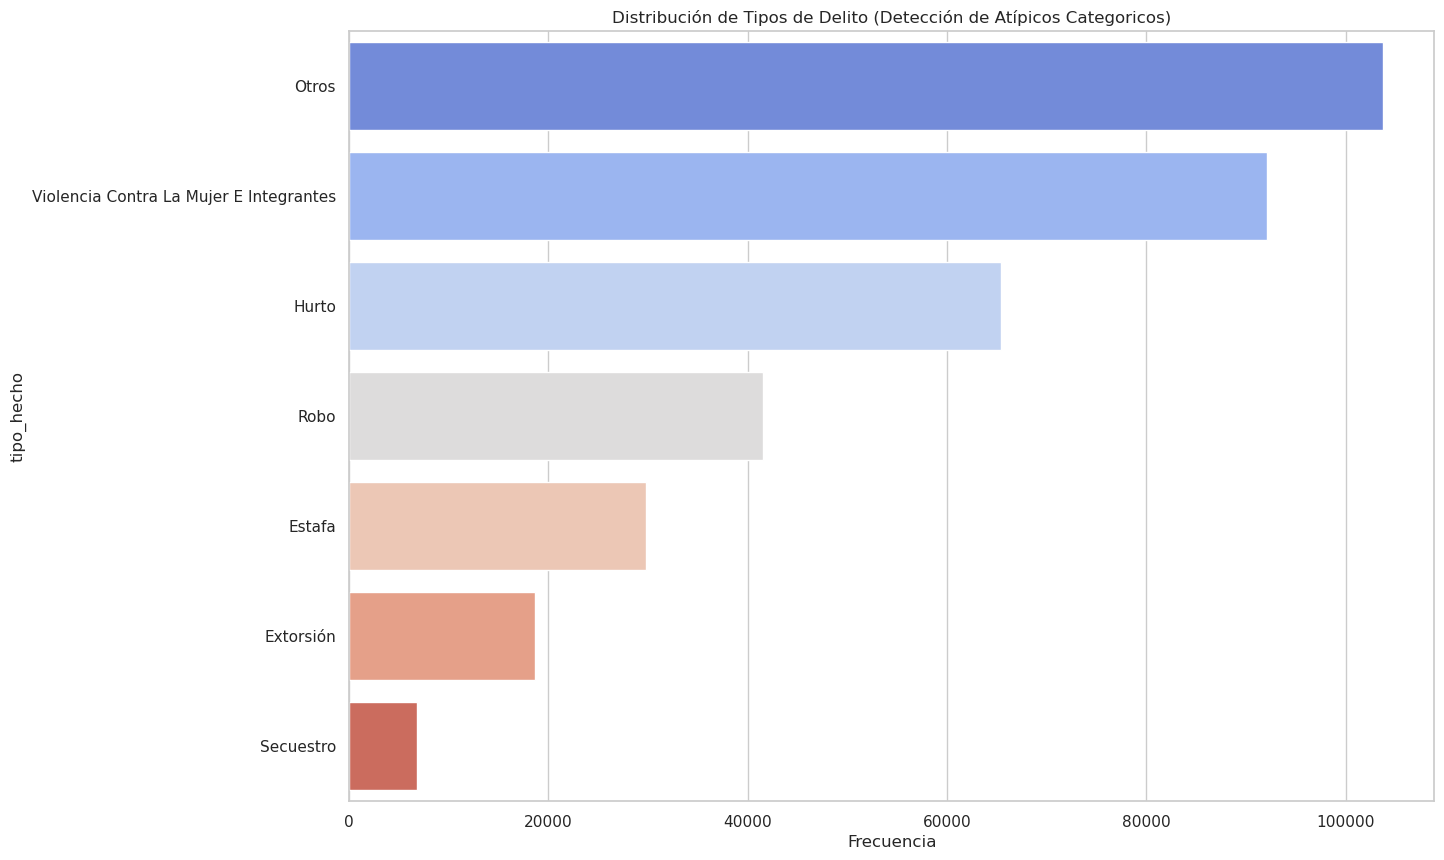

In [ ]:
# ======================================================================
# 3. Variable Categórica: Modalidad (Tipo de Delito)
# Mostramos todas las categorías criminales para descartar que haya clasificaciones anómalas 
# ingresadas por las comisarías, o detectar delitos de frecuencia sospechosamente baja.
# ======================================================================
tipo_counts = df["tipo_hecho"].value_counts()
plt.figure(figsize=(14, 10))
sns.barplot(x=tipo_counts.values, y=tipo_counts.index, palette="coolwarm")
plt.title("Distribución de Tipos de Delito (Detección de Atípicos Categoricos)")
plt.xlabel("Frecuencia")
plt.show()